# 1. Import Libraries and Load Dataset

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/sample_data/diabetes.csv")

# 2. Data Inspection and Variable Classification

In [65]:
print("=== DATASET DIMENSIONS ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

=== DATASET DIMENSIONS ===
Rows: 768, Columns: 9



In [67]:
print("=== SAMPLE RECORDS ===")
print(df.head(), "\n")

=== SAMPLE RECORDS ===
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1   



In [61]:
print("\n--- Class Distribution ---")
print(df['Outcome'].value_counts(normalize=True))


--- Class Distribution ---
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [68]:
print("=== DATA TYPES & MISSING VALUES ===")
print(df.info(), "\n")

=== DATA TYPES & MISSING VALUES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None 



# 3. Statistical Summary

In [69]:
print("=== STATISTICAL SUMMARY ===")
print(df.describe(), "\n")

=== STATISTICAL SUMMARY ===
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min    

# 4. Checking for missing or Invalid Values

In [70]:
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
hidden_missing = (df[invalid_zero_cols] == 0).sum()
print(hidden_missing)

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


# 5. Raw Feature Distribution

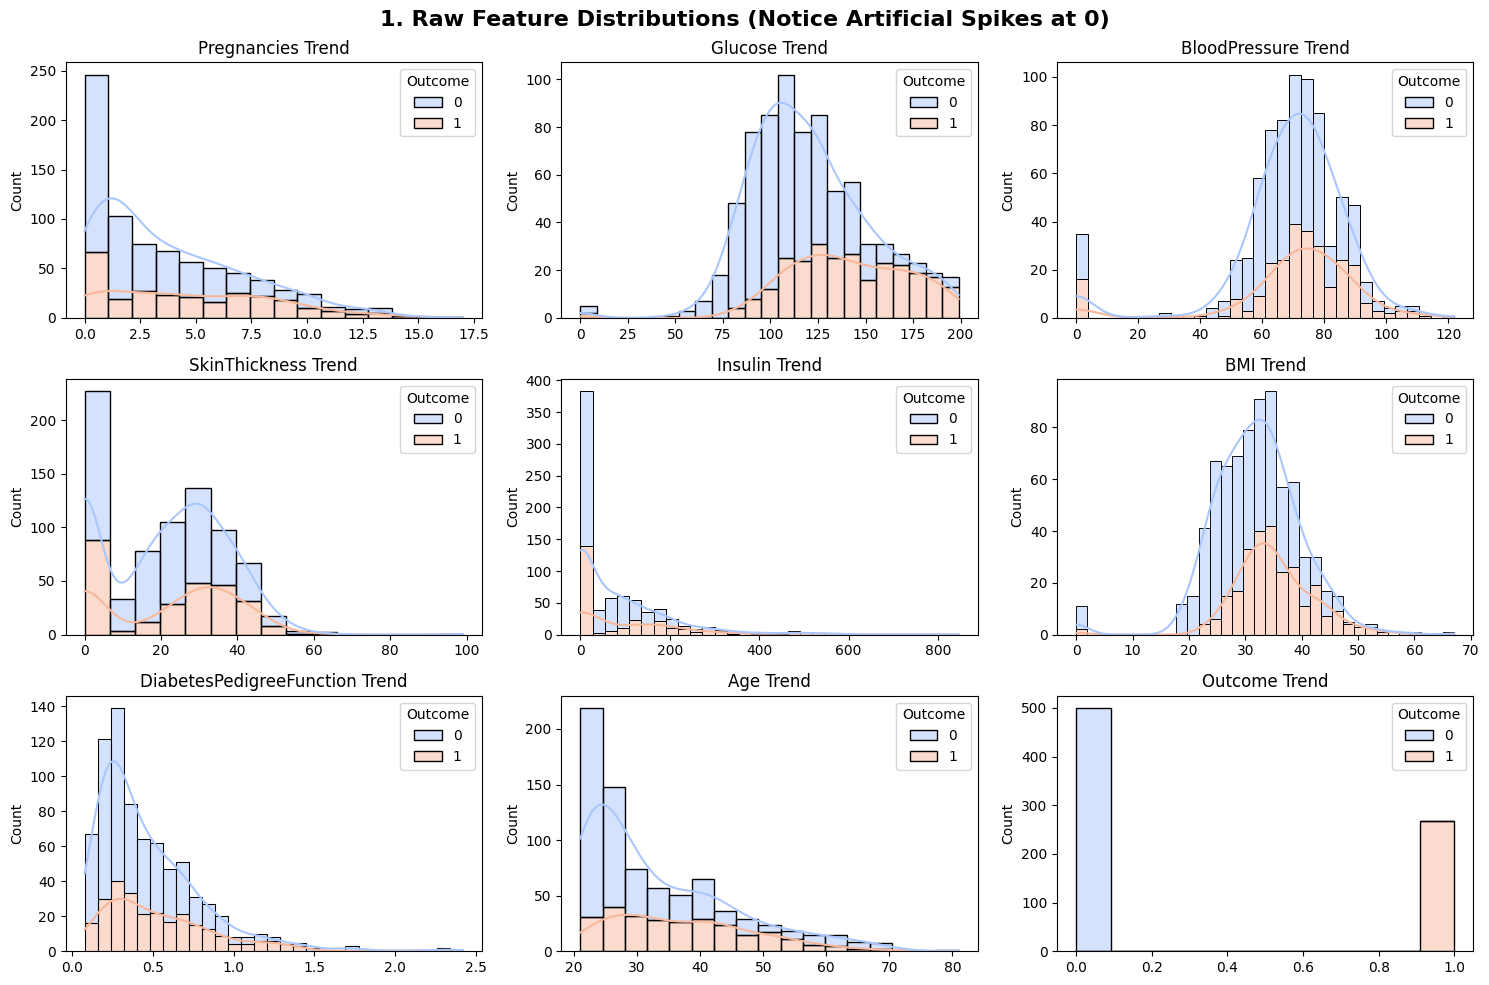

In [80]:
plt.figure(figsize=(15, 10))
plt.suptitle("1. Raw Feature Distributions (Notice Artificial Spikes at 0)", fontsize=16, fontweight='bold')

for i, col in enumerate(df[:-1], 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, multiple='stack', palette='coolwarm')
    plt.title(f'{col} Trend')
    plt.xlabel('')

plt.tight_layout()
plt.show()

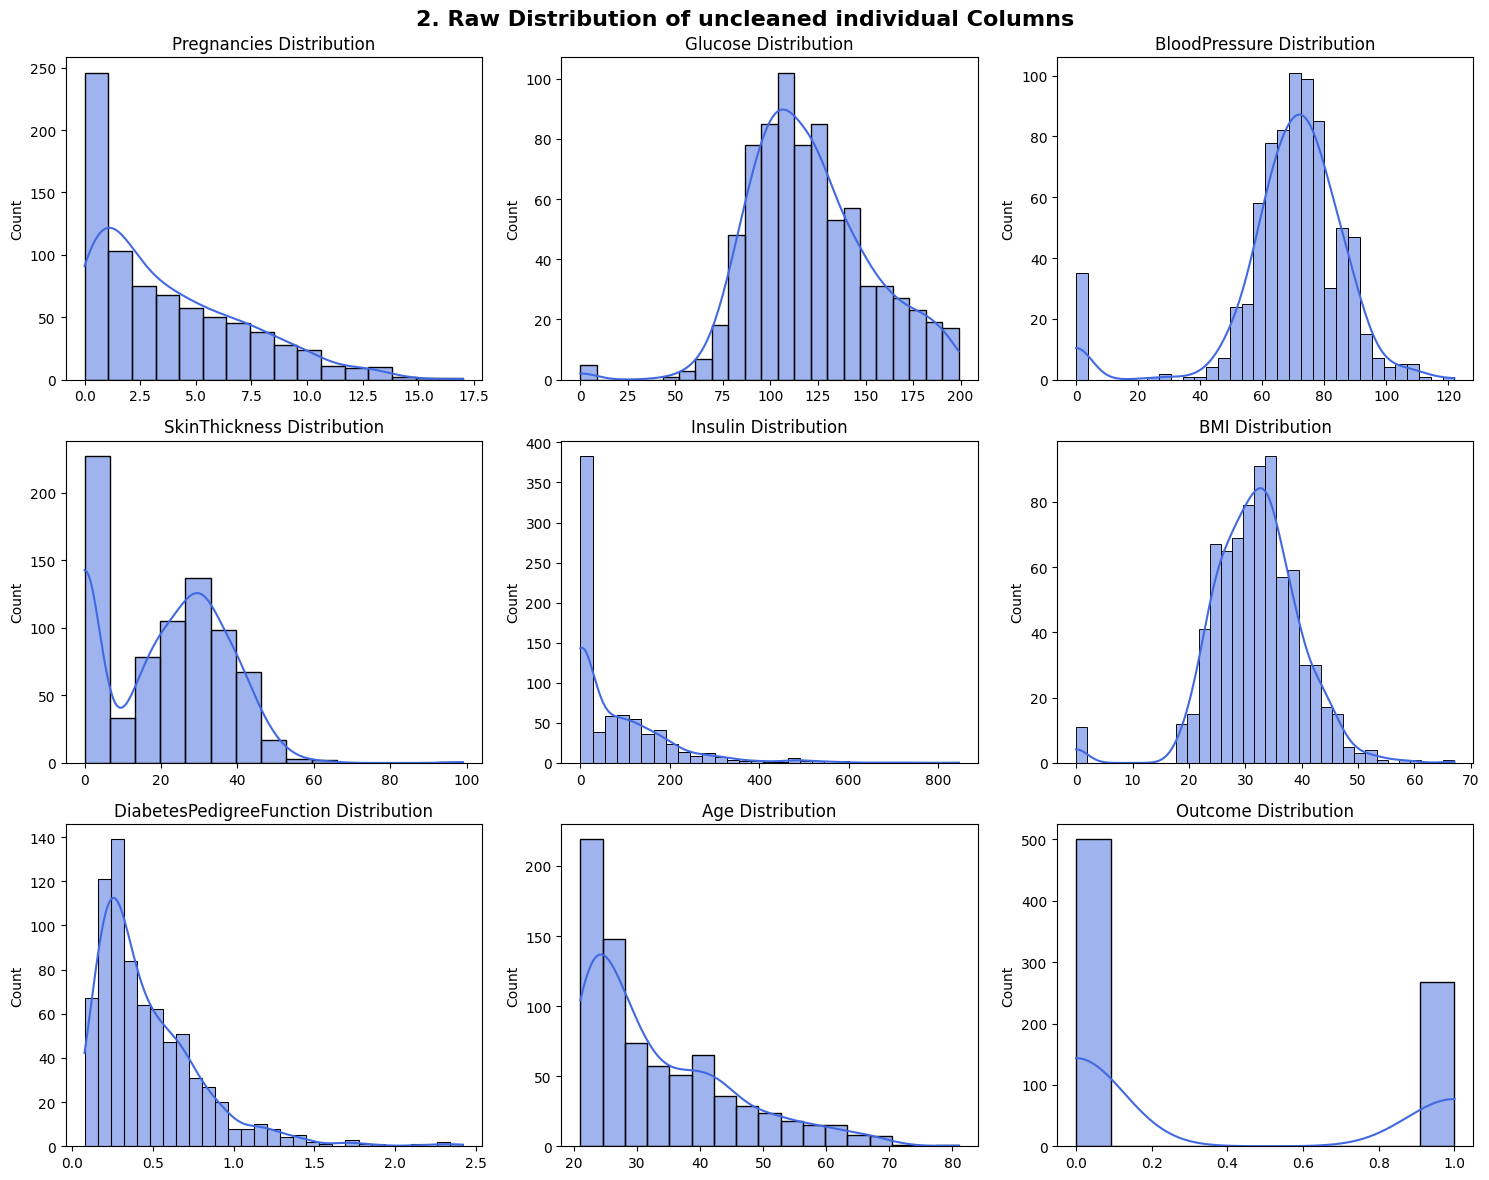

In [86]:
plt.figure(figsize=(15, 12))
plt.suptitle("2. Raw Distribution of uncleaned individual Columns", fontsize=16, fontweight='bold')

for i, col in enumerate(df.columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=df, x=col, kde=True, color='royalblue')
    plt.title(f'{col} Distribution')
    plt.xlabel('')

plt.tight_layout()
plt.show()

# 6. Outlier Detection

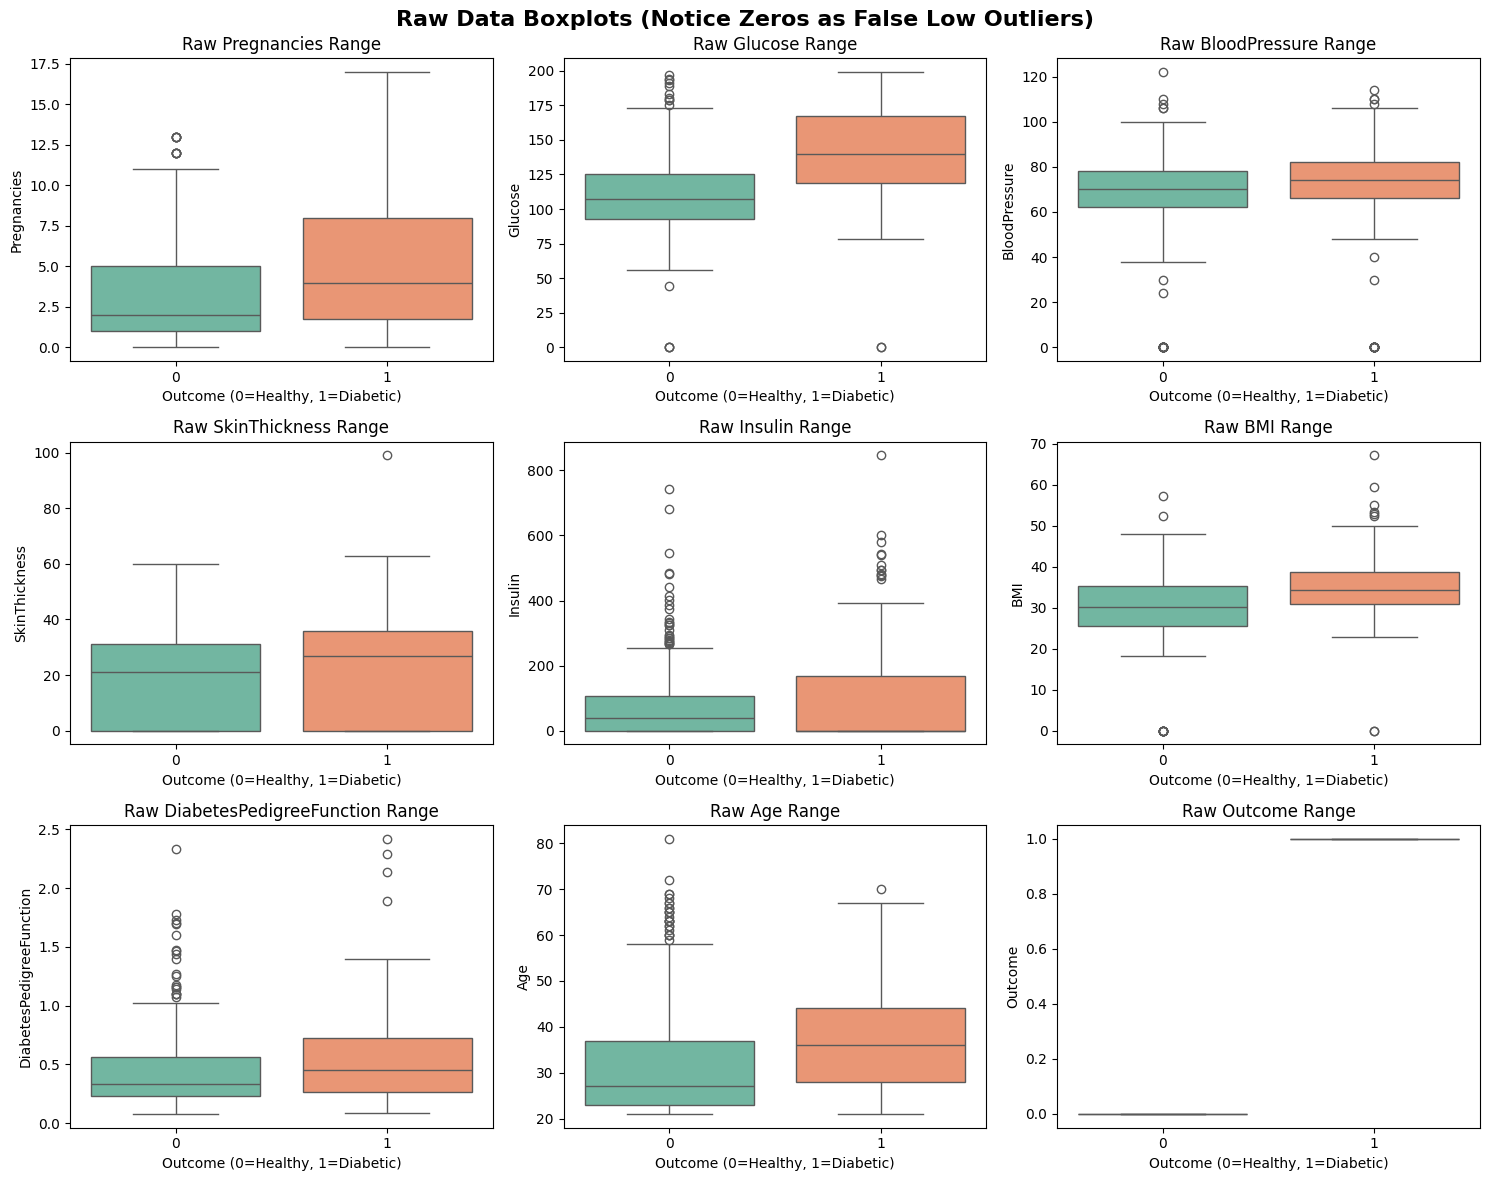

In [82]:
plt.figure(figsize=(15, 12))
plt.suptitle("Raw Data Boxplots (Notice Zeros as False Low Outliers)", fontsize=16, fontweight='bold')

for i, col in enumerate(df[:-1], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='Outcome', y=col, hue='Outcome', palette='Set2', legend=False)
    plt.title(f'Raw {col} Range')
    plt.xlabel('Outcome (0=Healthy, 1=Diabetic)')

plt.tight_layout()
plt.show()

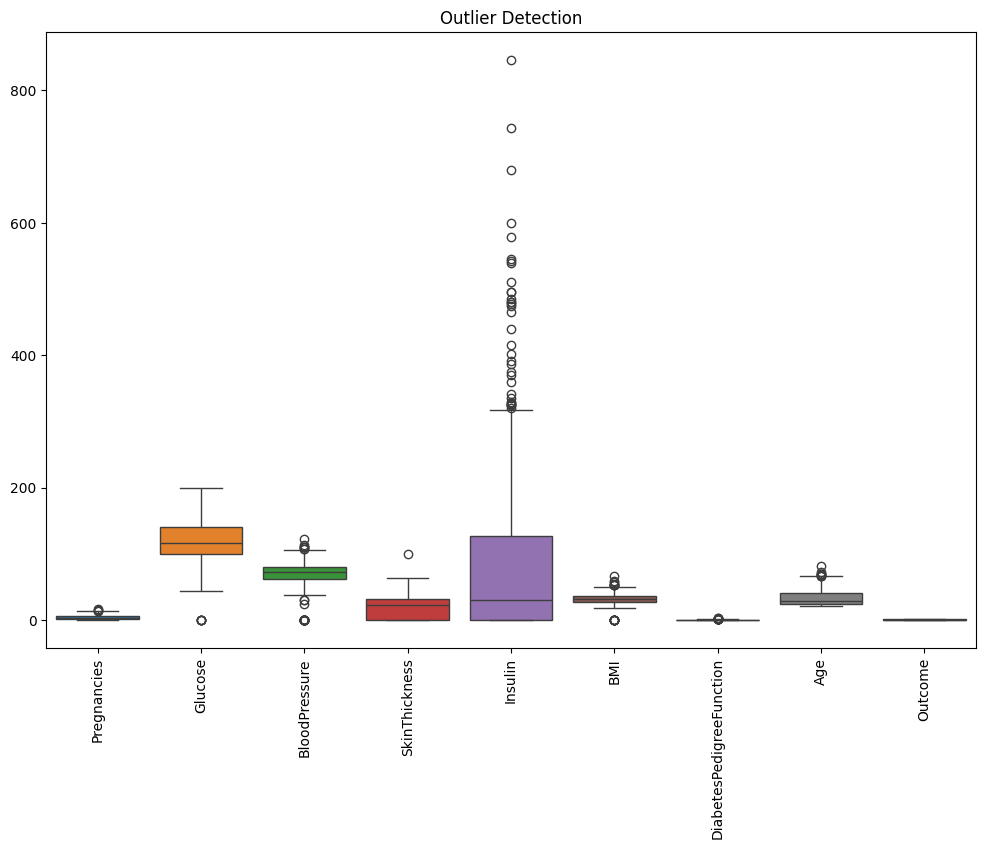

In [84]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.title('Outlier Detection')
plt.xticks(rotation=90)
plt.show()

# 7. Feature Relationships and Linear Relations

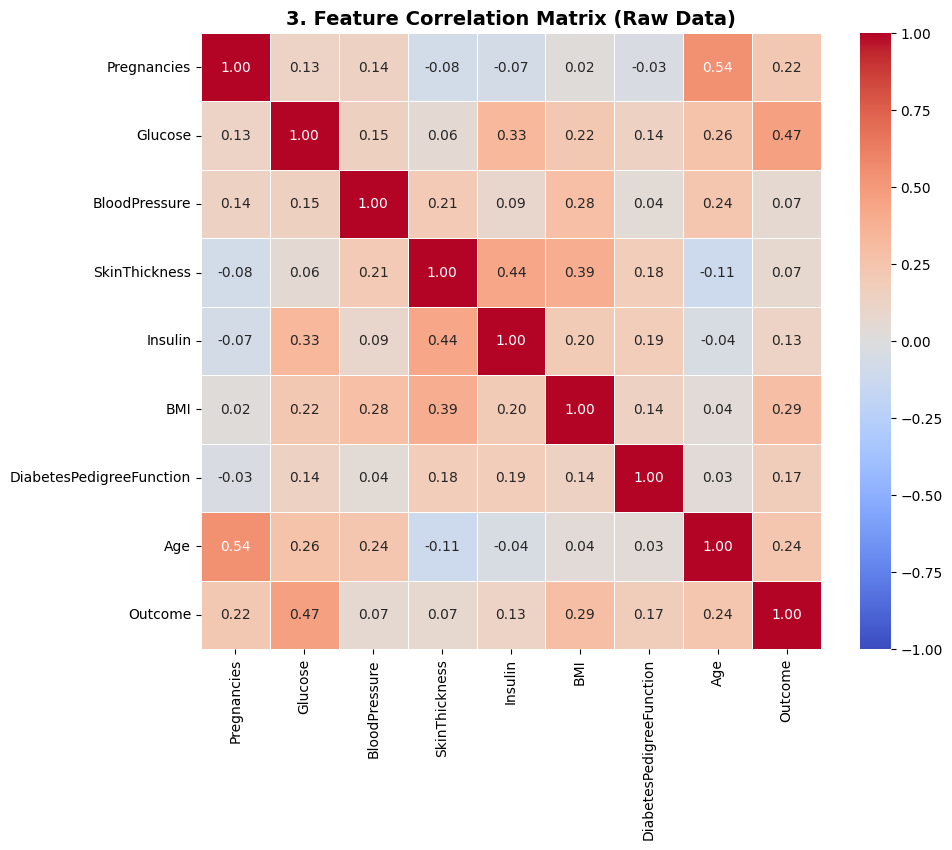

In [85]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("3. Feature Correlation Matrix (Raw Data)", fontsize=14, fontweight='bold')
plt.show()